(sec:frequentist-methods-for-outliers)=
# Frequentist methods to deal with outliers

In this section and the next we will use the data from {ref}`sec:SetupLinearRegressionOutliers`.


## Standard Likelihood Approach

We can maximize the likelihood (or, equivalently, minimize the loss) to find $\boldsymbol{\theta}$ within a frequentist paradigm. For a flat prior in $\boldsymbol{\theta}$, the maximum of the Bayesian posterior will yield the same result. (Note that there are good arguments based on the [principle of maximum entropy](https://nucleartalent.github.io/LFD_for_Physicists/content/BayesianStatistics/AssigningProbabilities/MaxEnt2.html) that a flat prior is not the best choice here; we'll ignore that detail for now, as it's a small effect for this problem.)

For simplicity, we'll use scipy's ``optimize`` package to minimize the loss (in the case of squared loss, this computation can be done more efficiently using matrix methods, but we'll use numerical minimization for simplicity here).

MLE: theta0 = 41.2, theta1 = 0.25


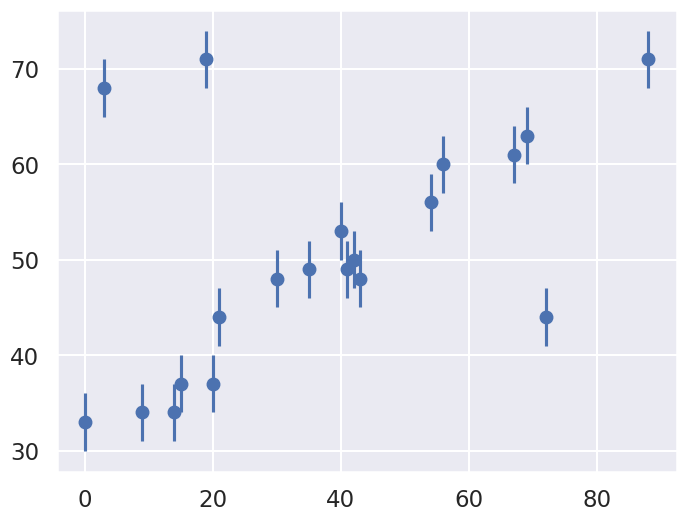

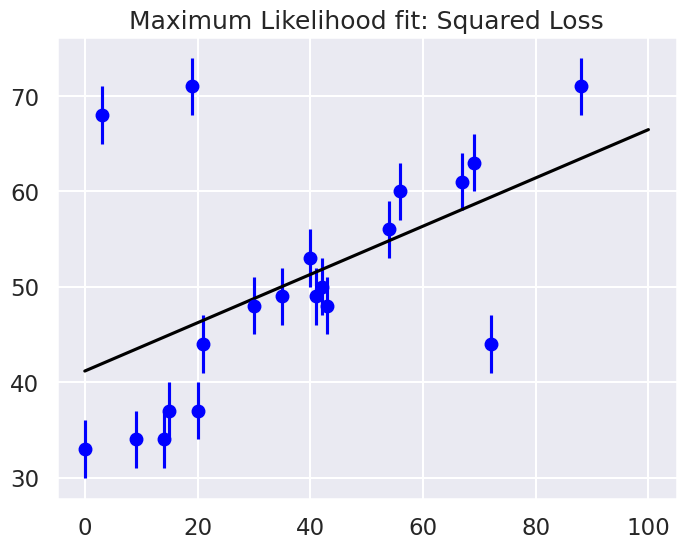

In [1]:
%matplotlib inline

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns; sns.set(); sns.set_context("talk")

import emcee
import corner

# note that x and y will be used as global arrays
x = np.array([ 0,  3,  9, 14, 15, 19, 20, 21, 30, 35,
              40, 41, 42, 43, 54, 56, 67, 69, 72, 88])
y = np.array([33, 68, 34, 34, 37, 71, 37, 44, 48, 49,
              53, 49, 50, 48, 56, 60, 61, 63, 44, 71])
sig0 = 3.
e = sig0*np.ones_like(y)

fig = plt.figure(figsize=(8,6))
ax = fig.add_subplot(1,1,1)
ax.errorbar(x, y, e, fmt='o');


def residuals(theta, x=x, y=y, sigma0=sig0):
    """
    Residuals between data y (a vector at points x) and the theoretical model,
    which here is a straight line with theta[0] = b and theta[1] = m.
    """
    delta_y = y - theta[0] - theta[1] * x
    return delta_y / sigma0

 
def log_posterior_gaussian(theta):
    """
    Returns the logarithm of the posterior, with a standard chi^2 likelihood 
    in terms of the residuals, with Gaussian errors as specified and a
    uniform prior assumed for theta between 0 and 100.
    """
    if (all(theta > 0) and all(theta < 100)):
        return -0.5 * np.sum(residuals(theta)**2)
    else:
        return -np.inf  # recall log(0) = -inf    

from scipy import optimize

def squared_loss(theta, x=x, y=y, sigma0=sig0):
    """Loss function is sum of squared residuals divided by 2, which
        is what we usually call chi^2 / 2. 
    """
    delta_y = y - theta[0] - theta[1] * x
    return np.sum(0.5 * (delta_y / sigma0) ** 2)

# Find the maximum likelihood estimate (MLE) for theta by minimizing the
#  square_loss function using scipy.optimize.fmin. (Minimizing chi^2 gives
#  the same result as maximizing e^{chi^2/2}.)
theta_MLE = optimize.fmin(squared_loss, [0, 0], disp=False)
print(f"MLE: theta0 = {theta_MLE[0]:.1f}, theta1 = {theta_MLE[1]:.2f}")

# Plot the MLE fit versus the data
xfit = np.linspace(0, 100)
yfit = theta_MLE[0] + theta_MLE[1] * xfit

fig, ax = plt.subplots(1, 1, figsize=(8,6))
ax.errorbar(x, y, sig0, fmt='o', color='blue')
ax.plot(xfit, yfit, color='black')
ax.set_title('Maximum Likelihood fit: Squared Loss');

It's clear on examination that the **outliers are exerting a disproportionate influence on the fit**. This is due to the nature of the squared loss function. If you have a single outlier that is, say 10 standard deviations away from the fit, its contribution to the loss will out-weigh that of 25 points which are 2 standard deviations away!

Clearly the squared loss is overly sensitive to outliers, and this is causing issues with our fit. One way to address this within the frequentist paradigm is to simply adjust the loss function to be more robust.

## Frequentist Correction for Outliers: Huber Loss

The variety of possible loss functions is quite literally infinite, but one relatively well-motivated option is the [Huber loss](http://en.wikipedia.org/wiki/Huber_loss_function). The Huber loss defines a critical value at which the loss curve transitions from quadratic to linear. Here is a plot that compares the Huber loss to the standard squared loss for several critical values $c$:

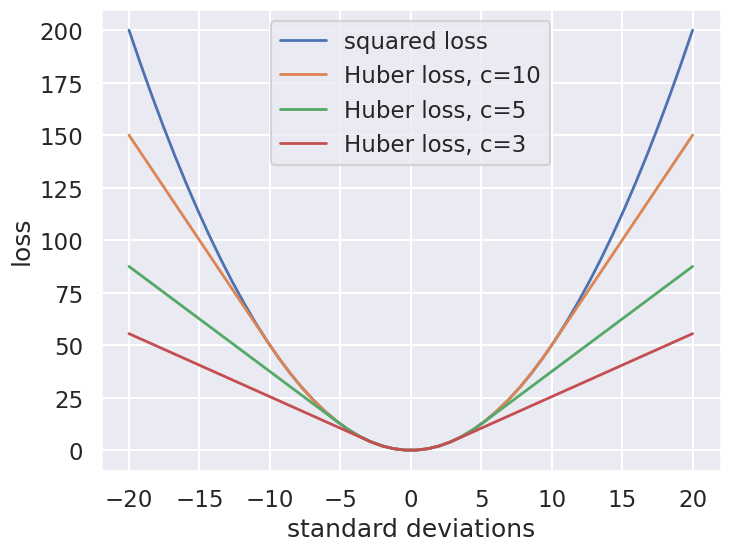

In [2]:
t = np.linspace(-20, 20)

def huber_loss(t, c=3):
    """
    Returns either a squared lost function or a linear (abolute value) loss
     function, depending on whether the |argument| is < c or >= c.
    """
    return ((abs(t) < c) * 0.5 * t ** 2
            + (abs(t) >= c) * -c * (0.5 * c - abs(t)))

fig, ax = plt.subplots(1, 1, figsize=(8,6))
ax.plot(t, 0.5 * t ** 2, label="squared loss", lw=2)
for c in (10, 5, 3):
    ax.plot(t, huber_loss(t, c), label=f"Huber loss, c={c}", lw=2)
ax.set(ylabel='loss', xlabel='standard deviations')
ax.legend(loc='best');

The Huber loss is equivalent to the squared loss for points that are well-fit by the model, but reduces the loss contribution of outliers. For example, a point 20 standard deviations from the fit has a squared loss of 200, but a c=3 Huber loss of just over 55. Let's see the result of the best-fit line using the Huber loss rather than the squared loss. We'll plot the squared loss result as a dashed gray line for comparison:

Huber: theta0 = 34.9, theta1 = 0.38


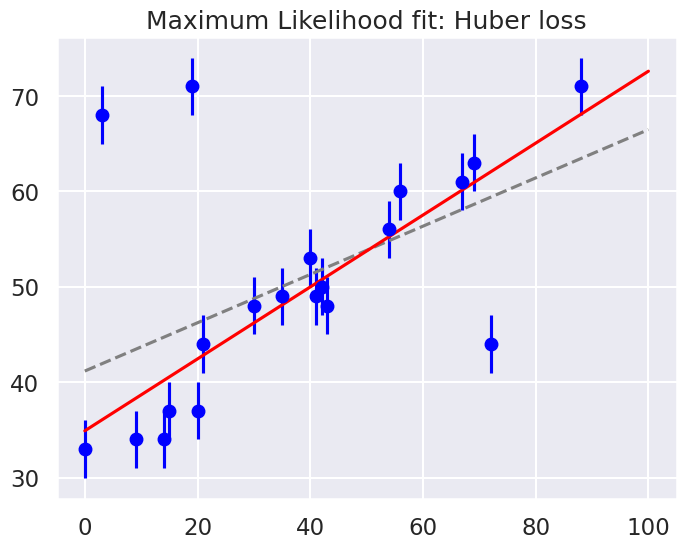

In [3]:
def total_huber_loss(theta, x=x, y=y, sigma0=sig0, c=3):
    return huber_loss((y - theta[0] - theta[1] * x) / sigma0, c).sum()

# minimize the total Huber loss for c=3
theta2 = optimize.fmin(total_huber_loss, [0, 0], disp=False)
print(f"Huber: theta0 = {theta2[0]:.1f}, theta1 = {theta2[1]:.2f}")

fig = plt.figure(figsize=(8,6))
ax = fig.add_subplot(1,1,1)
ax.errorbar(x, y, sig0, fmt='o', color='blue')
ax.plot(xfit, theta_MLE[0] + theta_MLE[1] * xfit, color='gray',ls='--')
ax.plot(xfit, theta2[0] + theta2[1] * xfit, color='red')
ax.set_title('Maximum Likelihood fit: Huber loss');

By eye, this seems to have worked as desired: the fit is much closer to our intuition!
*However, a Bayesian might point out that the motivation for this new loss function is a bit suspect: as we showed, the squared-loss can be straightforwardly derived from a Gaussian likelihood.*
* The Huber loss seems a bit *ad hoc*: where does it come from? 
* How should we decide what value of $c$ to use? 
* Is there any good motivation for using a linear loss on outliers, or should we simply remove them instead? 
* How might this choice affect our resulting model?*